# K-Means -- Cenário 2: Modelo para classificar clientes novos (com split)

**Quando usar este notebook:** quando o K-Means não é só uma análise
pontual -- ele vai virar um **modelo em produção**, que vai receber
clientes novos no futuro e dizer em qual grupo (já definido agora) cada um
se encaixa.

Aqui existe, sim, uma pergunta de generalização: "os grupos que aprendi
com os clientes de hoje continuam fazendo sentido para clientes que eu
ainda não vi?" -- por isso seguimos a mesma regra de ouro do K-NN:

> **Divide primeiro. `fit` (aprender) só no treino -- inclusive o próprio
> K-Means. O teste (e qualquer cliente novo no futuro) só passa por
> `transform`/`predict`, nunca por um novo `fit`.**

Base usada: `clientes_kmeans.csv` (mesma base do Cenário 1, para você
comparar os dois fluxos lado a lado).


## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
# Por quê: reprodutibilidade em todas as etapas aleatórias (split,
# inicialização do K-Means, simulação de sujeira).


## 2. Abrir o CSV

In [2]:
caminho_csv = "clientes_kmeans.csv"
df = pd.read_csv(caminho_csv)
print("Formato do dataset (linhas, colunas):", df.shape)
df.head()
# Por quê: mesma ideia do Cenário 1 -- carregar e conferir o arquivo.


Formato do dataset (linhas, colunas): (90, 7)


,cliente_id,idade,renda_mensal,visitas_mes,gasto_medio,dias_desde_ultima_compra,perfil_referencia
0,CLI001,31,1881,3,132.49,58,economico
1,CLI002,51,2408,3,220.06,46,economico
2,CLI003,51,2529,1,118.88,49,economico
3,CLI004,26,2769,2,91.25,60,economico
4,CLI005,28,4083,1,116.21,12,economico


## 3. Simular sujeira nos dados (só para fins didáticos)


In [3]:
rng = np.random.default_rng(RANDOM_STATE)
df_sujo = df.copy()

indices_nan = rng.choice(df_sujo.index, size=4, replace=False)
df_sujo.loc[indices_nan, "gasto_medio"] = np.nan
# Por quê: simula valores ausentes, como em dados reais.

indice_outlier = rng.choice(df_sujo.index)
df_sujo.loc[indice_outlier, "renda_mensal"] = 400000
# Por quê: simula um erro de medição para testarmos o tratamento de
# outliers mais adiante.

df = df_sujo


## 4. Dividir treino e teste ANTES de qualquer tratamento

Diferente do Cenário 1, aqui a divisão acontece logo no início -- exatamente
como fizemos no notebook do K-NN.


In [4]:
colunas_features = [
    "idade",
    "renda_mensal",
    "visitas_mes",
    "gasto_medio",
    "dias_desde_ultima_compra",
]
X = df[colunas_features].copy()
perfil_referencia = df["perfil_referencia"]
# Por quê guardar perfil_referencia à parte: é só um rótulo de conferência
# deste dataset didático -- não entra no treinamento do K-Means (que é não
# supervisionado) nem é usado para "ensinar" nada ao modelo.

X_train, X_test, ref_train, ref_test = train_test_split(
    X, perfil_referencia,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=perfil_referencia,
)
# Por quê test_size=0.30: reserva 30% dos "clientes" para simular clientes
# que só vão aparecer depois -- nunca usados para aprender os grupos.
# Por quê stratify=perfil_referencia: aqui usamos esse rótulo só para manter
# a mesma proporção dos 3 perfis em treino e teste -- é um recurso do
# dataset didático; sem esse rótulo, você faria a divisão sem stratify.

print("Treino:", X_train.shape, " Teste:", X_test.shape)


Treino: (63, 5)  Teste: (27, 5)


## 5. Tratar valores ausentes -- aprender (fit) só no treino


In [5]:
imputer = SimpleImputer(strategy="median")
X_train_imputado = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=colunas_features,
    index=X_train.index,
)
# Por quê fit_transform no treino: a mediana usada para preencher ausentes é
# calculada só com os clientes de treino.

X_test_imputado = pd.DataFrame(
    imputer.transform(X_test),
    columns=colunas_features,
    index=X_test.index,
)
# Por quê só transform no teste: usamos a MESMA mediana aprendida no
# treino -- o teste representa clientes "do futuro", que não podem
# influenciar essa estatística.


## 6. Tratar outliers -- limites calculados só com o treino

In [6]:
def calcular_limites_iqr(serie_treino):
    q1 = serie_treino.quantile(0.25)
    q3 = serie_treino.quantile(0.75)
    iqr = q3 - q1mask_raca
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr
# Por quê função separada: reforça que os limites vêm só do treino.

limites = {coluna: calcular_limites_iqr(X_train_imputado[coluna]) for coluna in colunas_features}

X_train_tratado = X_train_imputado.copy()
X_test_tratado = X_test_imputado.copy()
for coluna in colunas_features:
    limite_inf, limite_sup = limites[coluna]
    X_train_tratado[coluna] = X_train_tratado[coluna].clip(limite_inf, limite_sup)
    X_test_tratado[coluna] = X_test_tratado[coluna].clip(limite_inf, limite_sup)
# Por quê aplicar os limites do treino também no teste (sem recalcular):
# tratamos o teste como se fossem clientes chegando agora -- eles são
# ajustados pela régua que já existia, não redefinem a régua.

print("Limites de renda_mensal (aprendidos no treino):", limites["renda_mensal"])


Limites de renda_mensal (aprendidos no treino): (np.float64(-7477.0), np.float64(21595.0))


## 7. Padronizar -- fit no treino, transform no teste

In [7]:
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_tratado)
# Por quê fit_transform no treino: média e desvio-padrão usados na escala
# vêm só do treino.

X_test_final = scaler.transform(X_test_tratado)
# Por quê só transform no teste: aplicamos a MESMA escala aprendida no
# treino -- fundamental para que a distância calculada pelo K-Means no
# teste seja compatível com a distância usada para formar os grupos.


## 8. Escolher k -- testado e decidido usando só o treino

A escolha de k também é um "aprendizado" sobre os dados -- por isso os
gráficos usam só `X_train_final`, nunca o teste.


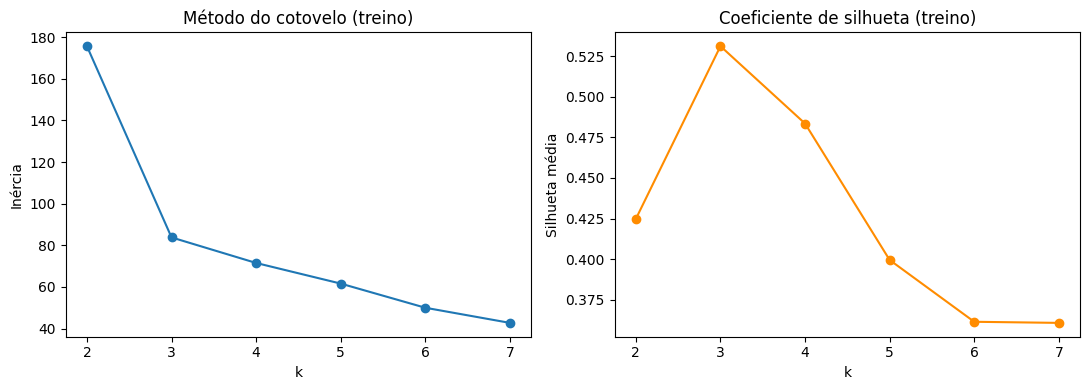

In [8]:
valores_k = range(2, 8)
inercias = []
silhuetas = []

for k in valores_k:
    modelo_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = modelo_k.fit_predict(X_train_final)
    inercias.append(modelo_k.inertia_)
    silhuetas.append(silhouette_score(X_train_final, labels_k))
# Por quê só com X_train_final: se usássemos o teste aqui, ele ajudaria a
# decidir a própria estrutura do modelo (quantos grupos existem) -- um tipo
# de vazamento de informação do teste para uma decisão de modelagem.

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set_title("Método do cotovelo (treino)")
eixos[0].set_xlabel("k")
eixos[0].set_ylabel("Inércia")

eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set_title("Coeficiente de silhueta (treino)")
eixos[1].set_xlabel("k")
eixos[1].set_ylabel("Silhueta média")
plt.tight_layout()
plt.show()


## 9. Treinar o K-Means final -- só com o treino

In [9]:
K_ESCOLHIDO = 3
modelo_kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
labels_train = modelo_kmeans.fit_predict(X_train_final)
# Por quê fit_predict só no treino: os centróides dos 3 grupos são
# definidos EXCLUSIVAMENTE com os clientes de treino -- o teste ainda não
# participou de nada até aqui.

print("Centróides (em espaço padronizado):")
print(modelo_kmeans.cluster_centers_.round(2))


Centróides (em espaço padronizado):
[[-0.76 -0.24  1.14 -0.36 -0.85]
 [ 0.19 -1.04 -1.02 -0.96  1.16]
 [ 0.57  1.28 -0.12  1.31 -0.31]]


## 10. Aplicar o modelo já treinado no teste -- só `predict`, nunca `fit`

Este é o passo que corresponde ao "Step 3" do diagrama da regra de ouro:
o teste só gira a engrenagem (`predict`), sem mexer no cadeado (`fit`).


In [10]:
labels_test = modelo_kmeans.predict(X_test_final)
# Por quê predict (e não fit_predict): os clientes de teste são atribuídos
# aos centróides que JÁ EXISTIAM, aprendidos só com o treino -- exatamente
# como aconteceria com um cliente novo chegando amanhã.

silhueta_treino = silhouette_score(X_train_final, labels_train)
silhueta_teste = silhouette_score(X_test_final, labels_test)
print(f"Silhueta no treino: {silhueta_treino:.3f}")
print(f"Silhueta no teste:  {silhueta_teste:.3f}")
# Por quê comparar as duas: se a silhueta do teste for parecida com a do
# treino, é um bom sinal de que os grupos aprendidos generalizam para
# clientes que o modelo não usou para se formar. Uma queda grande sugere
# que os grupos podem não fazer tanto sentido fora do treino.


Silhueta no treino: 0.531
Silhueta no teste:  0.524


## 11. Interpretar os grupos (com base no treino)

In [11]:
X_train_interpretacao = X_train_tratado.copy()
X_train_interpretacao["cluster"] = labels_train
perfil_dos_grupos = X_train_interpretacao.groupby("cluster")[colunas_features].mean().round(1)
print(perfil_dos_grupos)
# Por quê usar X_train_tratado (não padronizado) aqui: fica mais fácil de
# interpretar em termos de negócio (idade, renda em R$, etc.) do que olhar
# os valores já escalados.

print("\nComparação com o rótulo de referência no TESTE (só para conferência):")
print(pd.crosstab(labels_test, ref_test.values))
# Por quê conferir no teste: reforça a ideia de que os clusters aprendidos
# no treino continuam batendo com os perfis esperados em clientes que o
# modelo não usou para se formar.


         idade  renda_mensal  visitas_mes  gasto_medio  \
cluster                                                  
0         34.4        5991.7          7.7        378.7   
1         44.7        3002.7          2.2        119.9   
2         48.9       11602.3          4.5       1099.8   

         dias_desde_ultima_compra  
cluster                            
0                             7.6  
1                            40.4  
2                            16.5  

Comparação com o rótulo de referência no TESTE (só para conferência):
col_0  economico  frequente  premium
row_0                               
0              0          9        0
1              9          0        0
2              0          0        9


## 12. Aplicar em clientes genuinamente novos (simulação de produção)

Esta é a situação real que motivou separar treino/teste: chegam clientes
novos, e você só quer **encaixá-los** em um dos grupos já definidos -- sem
retreinar nada.


In [12]:
clientes_novos = pd.DataFrame({
    "idade": [24, 45, 33],
    "renda_mensal": [2100, 5200, 3300],
    "visitas_mes": [1, 5, 3],
    "gasto_medio": [70.0, 260.0, 140.0],
    "dias_desde_ultima_compra": [55, 8, 20],
})
# Por quê criar esses registros à mão: simula três clientes que acabaram de
# se cadastrar -- eles não existiam no CSV original.

clientes_novos_imputados = pd.DataFrame(
    imputer.transform(clientes_novos),
    columns=colunas_features,
)
clientes_novos_tratados = clientes_novos_imputados.copy()
for coluna in colunas_features:
    limite_inf, limite_sup = limites[coluna]
    clientes_novos_tratados[coluna] = clientes_novos_tratados[coluna].clip(limite_inf, limite_sup)
clientes_novos_escalados = scaler.transform(clientes_novos_tratados)
# Por quê só transform em cada etapa (imputer, clip com limites do treino,
# scaler): os clientes novos passam pela MESMA régua aprendida com o
# treino -- nunca recalculamos mediana, limites ou escala com base neles.

grupo_previsto = modelo_kmeans.predict(clientes_novos_escalados)
clientes_novos["cluster_previsto"] = grupo_previsto
print(clientes_novos)
# Por quê predict (não fit_predict): é a mesma lógica do Passo 10 -- os
# clientes novos são encaixados nos grupos que já existiam, sem alterar os
# centróides aprendidos no treino.


   idade  renda_mensal  visitas_mes  gasto_medio  dias_desde_ultima_compra  \
0     24          2100            1         70.0                        55   
1     45          5200            5        260.0                         8   
2     33          3300            3        140.0                        20   

   cluster_previsto  
0                 1  
1                 0  
2                 1  


## Resumo -- Cenário 2

- Divisão treino/teste **antes** de qualquer tratamento.
- Ausentes, outliers, escala **e o próprio K-Means** foram ajustados
  (`fit`) apenas com o treino.
- O teste (e os clientes novos simulados no final) passaram só por
  `transform`/`predict` -- nunca reaprenderam nada.
- A silhueta comparada entre treino e teste dá uma medida honesta de quão
  bem os grupos generalizam para clientes que o modelo não usou para se
  formar.

**Se o seu objetivo for só descrever a base que você já tem, sem aplicar o
modelo depois em dados novos**, use o notebook do **Cenário 1**, que é mais
simples e não precisa dessa divisão.
